In [1]:
from shutil import copy
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
from glob import glob
import psi4
import sys
sys.path.insert(0, os.path.join(os.path.expanduser('~'),'DDLUCJ/check_amplitudes/'))
from helper_CC_ML_spacial import *
import networkx as nx

  Threads set to 12 by Python driver.


In [2]:
# === 1. Molecule Setup ===
with open(os.path.join(os.path.expanduser('~'),'DDLUCJ/check_amplitudes/diatomics/HLi.xyz'),'r') as f:
    text=f.read()

qmol = psi4.qcdb.Molecule.from_string(text, dtype='xyz')
mol = psi4.geometry(qmol.create_psi4_string_from_molecule()+ 'symmetry c1')   


psi4.core.clean()
psi4.core.be_quiet()

# === 2. Set Options and Run RHF ===

psi4.set_options({'basis': 'STO-3G',
                  'scf_type':     'pk',
                  'reference':    'rhf',
                  'mp2_type':     'conv',
                  'e_convergence': 1e-8,
                  'd_convergence': 1e-8,
                  'print_mos': True                 
                 })

rhf_e, scf_wfn = psi4.energy('scf', return_wfn=True)

# === 3. Use HelperCCEnergy ===
A = HelperCCEnergy(mol, rhf_e, scf_wfn, freeze_core=True)
A.compute_energy()

# === 4. Define Active Space ===
n_frozen = A.nfzc  # automatically determined by HelperCCEnergy if freeze_core=True
nmo = A.nmo
active_orbitals = list(range(n_frozen, nmo))

num_orbitals = len(active_orbitals)
n_elec_total = A.ndocc * 2
active_elec = n_elec_total - 2 * n_frozen
num_elec_a = int((active_elec + mol.multiplicity() - 1) // 2)
num_elec_b = int((active_elec - mol.multiplicity() + 1) // 2)


# These are the MOs
Ca = scf_wfn.Ca()
# Ca = psi4.core.Matrix.from_array(cas.mo_coeff)
# Helper for integrals
basis = scf_wfn.basisset()
mints = psi4.core.MintsHelper(basis)

# Get the atomic orbital 1-el integrals <i|H|j>
Hao = mints.ao_kinetic()
Hao.add(mints.ao_potential())

# Transform them into molecular orbital representation
Hmo = psi4.core.triplet(Ca, Hao, Ca, True, False, False)

# Number of frozen orbitals
Nf = n_frozen

# ERIs in the MO basis 
Rm = mints.mo_eri(Ca, Ca, Ca, Ca).np

efc = 2*np.trace(Hmo.np[:Nf,:Nf]) +\
        2*np.einsum('iijj', Rm[:Nf,:Nf,:Nf,:Nf]) -\
        np.einsum('ijij', Rm[:Nf,:Nf,:Nf,:Nf])

nuclear_repulsion_energy = efc + mol.nuclear_repulsion_energy()
print('Frozen core energy: ', nuclear_repulsion_energy)




# === 5. Extract Active-Space Integrals ===
hcore = A.H1[np.ix_(active_orbitals, active_orbitals)]
hcore_psi4 = hcore
# Get full MO ERI tensor and slice to active space
# No slicing — this is already the active-space ERI
eri = A.MO


# === 6. Use CCSD Final Energy as "exact" reference ===
exact_energy = A.FinalEnergy + rhf_e

# === 7. Optionally run Psi4’s built-in CCSD for comparison ===
psi4.set_options({'freeze_core': 'true'})
ccsd_e, ccsd_wfn = psi4.energy('ccsd', return_wfn=True)

# === 8. Extract Amplitudes ===
t1 = A.t1
t2 = A.t2

# === 9. Print Summary ===
print("CCSD correlation energy (Helper):", A.ccsd_corr_e)
print("Total CCSD energy (Helper):      ", A.FinalEnergy)
print("H1 shape:", hcore.shape)
print("ERI shape:", eri.shape)
print("Active electrons: (α, β) =", (num_elec_a, num_elec_b))
print("Exact (CCSD) Energy:", exact_energy)


Computing RHF reference.
Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 6 basis functions.
(6, 6)
(5, 5)
Building initial guess...

..initialized CCSD in 0.002 seconds.

CCSD Iteration   0: CCSD correlation = -0.012592560801913   dE =  1.25926E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.017024114490341   dE = -4.43155E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.018703334087822   dE = -1.67922E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.019809445227367   dE = -1.10611E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.020006127884664   dE = -1.96683E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.020068758226443   dE = -6.26303E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.020057947032657   dE =  1.08112E-05   DIIS = 5
CCSD Iteration   7: CCSD correlation = -0.020060378113906   dE = -2.43108E-06   DIIS = 6
CCSD Iteration   8: CCSD correlation = -0.02

/Users/grierjones/DDLUCJ/check_amplitudes/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/Users/grierjones/DDLUCJ/check_amplitudes/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/Users/grierjones/DDLUCJ/check_amplitudes/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})
/Users/grierjones/DDLUCJ/check_amplitudes/helper_CC_ML_spac

CCSD correlation energy (Helper): -0.020059311077221795
Total CCSD energy (Helper):       -0.020059311077221795
H1 shape: (5, 5)
ERI shape: (5, 5, 5, 5)
Active electrons: (α, β) = (1, 1)
Exact (CCSD) Energy: -7.882254452324073


array([[ 9.91239569e-01,  1.67794888e-01,  2.09905403e-01,
         1.95830155e-16, -6.37690387e-17,  9.21431529e-02],
       [ 3.26459733e-02, -4.54296465e-01, -7.99700724e-01,
        -7.06004246e-16,  8.22165271e-17, -7.06970291e-01],
       [ 6.39027733e-03,  3.46396084e-01, -6.12209419e-01,
        -8.42400145e-16, -3.41846547e-16,  9.82700836e-01],
       [-6.58039713e-16, -2.93436042e-16, -4.76318957e-16,
         4.83805638e-01,  8.75175471e-01,  3.20620343e-16],
       [ 2.38925161e-17,  2.98593888e-16, -5.45602162e-16,
         8.75175471e-01, -4.83805638e-01,  6.51705439e-17],
       [ 4.60100617e-03, -5.48458342e-01,  1.39389635e-01,
        -1.45229791e-16, -5.06628459e-16,  1.19028898e+00]])

In [34]:
Ca_check = scf_wfn.Ca().to_array().copy()

Ca_check[[3,5]]=Ca_check[[5,3]]

# H_check = scf_wfn.H().to_array()
# H_check[[3,5]]=H_check[[5,3]]
# H_check[[4,3]]=H_check[[3,4]]

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


In [32]:
scf_wfn.epsilon_a().to_array()

array([-2.34851712, -0.28617966,  0.07831086,  0.16393438,  0.16393438,
        0.55068153])

In [35]:
Ca_check

array([[ 0.00460101,  0.54845834,  0.13938964,  0.        ,  0.        ,
         1.19028898],
       [ 0.99123957, -0.16779489,  0.2099054 ,  0.        ,  0.        ,
         0.09214315],
       [ 0.03264597,  0.45429647, -0.79970072,  0.        ,  0.        ,
        -0.70697029],
       [-0.        ,  0.        ,  0.        ,  0.        ,  1.        ,
         0.        ],
       [-0.        ,  0.        ,  0.        ,  1.        ,  0.        ,
         0.        ],
       [ 0.00639028, -0.34639608, -0.61220942,  0.        ,  0.        ,
         0.98270084]])

In [28]:
H_check

array([[-1.46272923, -0.30932533, -0.69986273,  0.84366962,  0.        ,
         0.        ],
       [-0.30932533, -4.73905626, -1.06486519,  0.01631548,  0.        ,
         0.        ],
       [-0.69986273, -1.06486519, -1.39703981,  0.12275254,  0.        ,
         0.        ],
       [ 0.        ,  0.        ,  0.        ,  0.        , -1.13680162,
         0.        ],
       [ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        -1.13680162],
       [ 0.84366962,  0.01631548,  0.12275254, -1.23545179,  0.        ,
         0.        ]])

In [ ]:
3 4 5
0, +1, -1

In [11]:
4  3  5
+1 0 -1

(0, 1, -1)

array([[-1.46272923, -0.30932533, -0.69986273,  0.84366962,  0.        ,
         0.        ],
       [-0.30932533, -4.73905626, -1.06486519,  0.01631548,  0.        ,
         0.        ],
       [-0.69986273, -1.06486519, -1.39703981,  0.12275254,  0.        ,
         0.        ],
       [ 0.84366962,  0.01631548,  0.12275254, -1.23545179,  0.        ,
         0.        ],
       [ 0.        ,  0.        ,  0.        ,  0.        , -1.13680162,
         0.        ],
       [ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        -1.13680162]])

In [5]:
Hmo.to_array()

array([[-4.72960017e+00, -1.05894029e-01, -1.67087138e-01,
         8.38409702e-17, -2.92403569e-17, -3.38355274e-02],
       [-1.05894029e-01, -1.49678213e+00,  3.31922983e-02,
         4.02371112e-16, -9.06170679e-17,  5.57061928e-02],
       [-1.67087138e-01,  3.31922983e-02, -1.12627040e+00,
         2.91271904e-16, -5.52555292e-17, -3.06473289e-02],
       [ 8.38409702e-17,  4.02371112e-16,  2.91271904e-16,
        -1.13680162e+00,  1.27925337e-16,  1.80777853e-16],
       [-2.92403569e-17, -9.06170679e-17, -5.52555292e-17,
         1.21767109e-16, -1.13680162e+00, -1.53806304e-17],
       [-3.38355274e-02,  5.57061928e-02, -3.06473289e-02,
         1.80777853e-16, -1.53806304e-17, -9.49119115e-01]])

In [6]:
eri

array([[[[ 4.88053129e-01, -4.83988574e-02,  9.51881340e-17,
          -1.65824629e-16, -1.27347292e-01],
         [-4.83988574e-02,  1.29574951e-02, -5.92737019e-18,
           1.71727930e-18,  3.44736600e-02],
         [ 9.51881340e-17, -5.92737019e-18,  2.34814804e-02,
          -2.87089156e-18, -6.82477431e-17],
         [-1.65824629e-16,  1.71727930e-18, -2.86631576e-18,
           2.34814804e-02, -1.00504810e-17],
         [-1.27347292e-01,  3.44736600e-02, -6.82477431e-17,
          -1.00504810e-17,  1.23811317e-01]],

        [[-4.83988574e-02,  2.23916952e-01,  5.06227277e-17,
          -4.69461093e-17,  5.13116672e-02],
         [ 1.29574951e-02,  7.34305585e-03,  1.38930852e-17,
          -9.60665156e-18, -9.29957878e-03],
         [-5.92737019e-18,  2.65807217e-17,  1.92678575e-02,
          -2.43650529e-18,  4.10154142e-17],
         [ 1.71727930e-18, -1.21937956e-16, -2.36249501e-18,
           1.92678575e-02, -4.18010377e-18],
         [ 3.44736600e-02,  1.21320973e-02, 

In [7]:
t1

array([[ 3.84857075e-02,  4.43811059e-16,  4.43056399e-16,
        -3.64071617e-03]])

In [8]:
t2

array([[[[-3.60939574e-02,  3.30905542e-17, -5.84745441e-17,
          -5.94908909e-02],
         [ 3.30905542e-17, -2.77582804e-02, -1.91383943e-18,
           5.97482161e-17],
         [-5.84745441e-17, -1.66359209e-18, -2.77582804e-02,
          -9.97879237e-17],
         [-5.94908909e-02,  5.97482161e-17, -9.97879237e-17,
          -1.14670033e-01]]]])

In [4]:
import ffsim
from qiskit import QuantumCircuit, QuantumRegister

n_reps = 1
alpha_alpha_indices = [(p, p + 1) for p in range(num_orbitals - 1)]
alpha_beta_indices = [(p, p) for p in range(0, num_orbitals, 4)]

ucj_op = ffsim.UCJOpSpinBalanced.from_t_amplitudes(
    t2=t2,
    t1=t1,
    n_reps=n_reps,
    interaction_pairs=(alpha_alpha_indices, alpha_beta_indices),
)

nelec = (num_elec_a, num_elec_b)

# create an empty quantum circuit
qubits = QuantumRegister(2 * num_orbitals, name="q")
circuit = QuantumCircuit(qubits)

# prepare Hartree-Fock state as the reference state and append it to the quantum circuit
circuit.append(ffsim.qiskit.PrepareHartreeFockJW(num_orbitals, nelec), qubits)

# apply the UCJ operator to the reference state
circuit.append(ffsim.qiskit.UCJOpSpinBalancedJW(ucj_op), qubits)
circuit.measure_all()

In [6]:
from qiskit_ibm_runtime import QiskitRuntimeService

service = QiskitRuntimeService()

backend = service.backend("ibm_strasbourg")

In [7]:
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

spin_a_layout = [0, 14, 18, 19, 20, 33, 39, 40, 41, 53, 60, 61, 62, 72, 81, 82]
spin_b_layout = [2, 3, 4, 15, 22, 23, 24, 34, 43, 44, 45, 54, 64, 65, 66, 73]
initial_layout = spin_a_layout + spin_b_layout

pass_manager = generate_preset_pass_manager(
    optimization_level=3, backend=backend, initial_layout=initial_layout
)

# without PRE_INIT passes
isa_circuit = pass_manager.run(circuit)
print(f"Gate counts (w/o pre-init passes): {isa_circuit.count_ops()}")

# with PRE_INIT passes
# We will use the circuit generated by this pass manager for hardware execution
pass_manager.pre_init = ffsim.qiskit.PRE_INIT
isa_circuit = pass_manager.run(circuit)
print(f"Gate counts (w/ pre-init passes): {isa_circuit.count_ops()}")

TranspilerError: 'The length of the layout is different than the size of the circuit: 32 <> 16'

In [10]:
from qiskit_ibm_runtime import SamplerV2 as Sampler

# sampler = Sampler(mode=backend)
# job = sampler.run([isa_circuit], shots=10_000)

job = service.job('d11h9w7v3z500082dp30')

In [11]:
primitive_result = job.result()
pub_result = primitive_result[0]
counts = pub_result.data.meas.get_counts()

In [12]:
from qiskit_addon_sqd.counts import counts_to_arrays

# Convert counts into bitstring and probability arrays
bitstring_matrix_full, probs_arr_full = counts_to_arrays(counts)

In [17]:
import numpy as np
from qiskit_addon_sqd.configuration_recovery import recover_configurations
from qiskit_addon_sqd.fermion import solve_fermion
from qiskit_addon_sqd.subsampling import postselect_and_subsample

rng = np.random.default_rng(12345)

# SQD options
iterations = 4

# Eigenstate solver options
n_batches = 5
samples_per_batch = 20000
max_davidson_cycles = 200

# Self-consistent configuration recovery loop
e_hist = np.zeros((iterations, n_batches))  # energy history
s_hist = np.zeros((iterations, n_batches))  # spin history
occupancy_hist = []
avg_occupancy = None
for i in range(iterations):
    print(f"Starting configuration recovery iteration {i}")
    # On the first iteration, we have no orbital occupancy information from the
    # solver, so we just post-select from the full bitstring set based on hamming weight.
    if avg_occupancy is None:
        bs_mat_tmp = bitstring_matrix_full
        probs_arr_tmp = probs_arr_full

    # If we have average orbital occupancy information, we use it to refine the full set of noisy configurations
    else:
        bs_mat_tmp, probs_arr_tmp = recover_configurations(
            bitstring_matrix_full,
            probs_arr_full,
            avg_occupancy,
            num_elec_a,
            num_elec_b,
            rand_seed=rng,
        )

    # Throw out configurations with incorrect particle number in either the spin-up or spin-down systems
    batches = postselect_and_subsample(
        bs_mat_tmp,
        probs_arr_tmp,
        hamming_right=num_elec_a,
        hamming_left=num_elec_b,
        samples_per_batch=samples_per_batch,
        num_batches=n_batches,
        rand_seed=rng,
    )

    # Run eigenstate solvers in a loop. This loop should be parallelized for larger problems.
    e_tmp = np.zeros(n_batches)
    s_tmp = np.zeros(n_batches)
    occs_tmp = []
    coeffs = []
    for j in range(n_batches):
        energy_sci, coeffs_sci, avg_occs, spin = solve_fermion(
            batches[j],
            hcore,
            eri,
            open_shell=open_shell,
            spin_sq=spin_sq,
            max_davidson=max_davidson_cycles,
        )
        energy_sci += nuclear_repulsion_energy
        e_tmp[j] = energy_sci
        s_tmp[j] = spin
        occs_tmp.append(avg_occs)
        coeffs.append(coeffs_sci)

    # Combine batch results
    avg_occupancy = np.mean(occs_tmp, axis=0)

    # Track optimization history
    e_hist[i, :] = e_tmp
    s_hist[i, :] = s_tmp
    occupancy_hist.append(avg_occupancy)

Starting configuration recovery iteration 0
Starting configuration recovery iteration 1
Starting configuration recovery iteration 2
Starting configuration recovery iteration 3


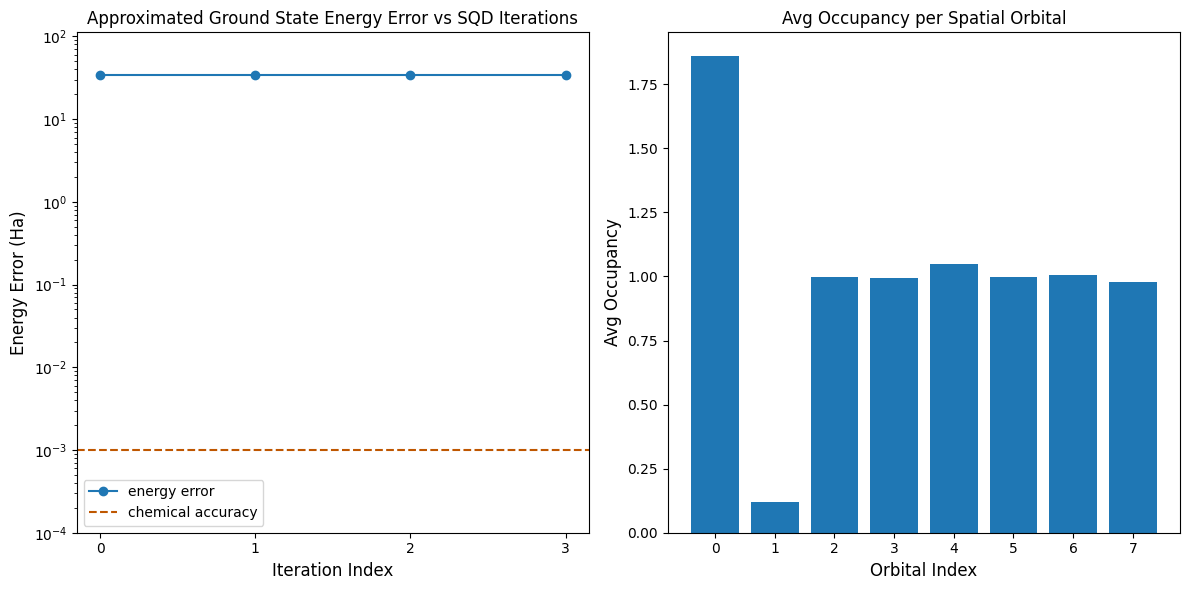

In [18]:
import matplotlib.pyplot as plt

# Data for energies plot
x1 = range(iterations)
e_diff = [abs(np.min(energies) - casci_e) for energies in e_hist]
yt1 = [1.0, 1e-1, 1e-2, 1e-3, 1e-4]

# Chemical accuracy (+/- 1 milli-Hartree)
chem_accuracy = 0.001

# Data for avg spatial orbital occupancy
y2 = occupancy_hist[-1][0] + occupancy_hist[-1][1]
x2 = range(len(y2))

fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Plot energies
axs[0].plot(x1, e_diff, label="energy error", marker="o")
axs[0].set_xticks(x1)
axs[0].set_xticklabels(x1)
axs[0].set_yticks(yt1)
axs[0].set_yticklabels(yt1)
axs[0].set_yscale("log")
axs[0].set_ylim(1e-4)
axs[0].axhline(y=chem_accuracy, color="#BF5700", linestyle="--", label="chemical accuracy")
axs[0].set_title("Approximated Ground State Energy Error vs SQD Iterations")
axs[0].set_xlabel("Iteration Index", fontdict={"fontsize": 12})
axs[0].set_ylabel("Energy Error (Ha)", fontdict={"fontsize": 12})
axs[0].legend()

# Plot orbital occupancy
axs[1].bar(x2, y2, width=0.8)
axs[1].set_xticks(x2)
axs[1].set_xticklabels(x2)
axs[1].set_title("Avg Occupancy per Spatial Orbital")
axs[1].set_xlabel("Orbital Index", fontdict={"fontsize": 12})
axs[1].set_ylabel("Avg Occupancy", fontdict={"fontsize": 12})

plt.tight_layout()
plt.show()